# Rope Flow — Full Pipeline V10

**Course:** MECH 798M / EECE 798K — Data-Driven Modeling  
**Pipeline:**
- Direct multivariate time-series cycle classification (`12x64` per cycle)
- Fixed-window cycle extraction centered on paired `||omega||` peaks
- LOSO evaluation for PCA+GBM and RF baselines
- Cycle-level reporting only (no session-level majority vote)


In [57]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import silhouette_score as _sil

np.random.seed(42)

# ── Paths ─────────────────────────────────────────────────────────────────
DATA_PROCESSED = os.path.join('..', '..', 'data', 'processed')

# ── Config ────────────────────────────────────────────────────────────────
DIRECT_CFG = {
    'FS':                 50.0,
    'WINDOW':             64,
    'PEAK_PROM_DEGS':     100.0,
    'PEAK_MIN_DEGS':      50.0,
    'PEAK_SAVGOL_WINDOW': 21,
    'PEAK_SAVGOL_POLY':   3,
    'PEAK_MIN_PERIOD_S':  0.5,
    'PEAK_PAIR_MAX_DT_S': 0.25,
    'N_CLUSTERS':         8,
}

# ── Results directory (new folder per run) ────────────────────────────────
import datetime
RUN_NAME    = datetime.datetime.now().strftime('run_%Y%m%d_%H%M%S')
RESULTS_DIR = os.path.join('..', '..', 'results', 'Full_pipeline', RUN_NAME)
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f'Results will be saved to: {RESULTS_DIR}')


Results will be saved to: ..\..\results\Full_pipeline\run_20260426_112445


### 1. Session discovery and cycle detection

In [58]:
# ── Session discovery ─────────────────────────────────────────────────────
def discover_direct_sessions(processed_dir):
    entries = []
    for d0 in sorted(glob.glob(os.path.join(processed_dir, '*_device0_processed.csv'))):
        d1 = d0.replace('_device0_', '_device1_')
        if not os.path.isfile(d1):
            continue
        stem = os.path.basename(d0).replace('_device0_processed.csv', '')
        entries.append((d0, d1, 'unlabeled', stem, None))
    return entries

# ── Cycle-extraction helpers ──────────────────────────────────────────────
def _smooth_mag_deg(omega_rad, cfg):
    mag_deg = np.linalg.norm(omega_rad, axis=1) * (180.0 / np.pi)
    n = len(mag_deg)
    if n < 7: return mag_deg
    win  = int(cfg['PEAK_SAVGOL_WINDOW'])
    if win % 2 == 0: win += 1
    max_odd = n if n % 2 == 1 else n - 1
    win  = max(5, min(win, max_odd))
    poly = max(1, min(int(cfg['PEAK_SAVGOL_POLY']), win - 2))
    y = savgol_filter(mag_deg, window_length=win, polyorder=poly, mode='interp')
    y = savgol_filter(y,       window_length=win, polyorder=poly, mode='interp')
    return y

def detect_cycle_peaks(omega_rad, fs, cfg):
    mag_smooth = _smooth_mag_deg(omega_rad, cfg)
    peaks, _   = find_peaks(
        mag_smooth,
        distance=max(1, int(cfg['PEAK_MIN_PERIOD_S'] * fs)),
        prominence=cfg['PEAK_PROM_DEGS'],
    )
    peaks = np.array([int(p) for p in peaks if mag_smooth[p] >= cfg['PEAK_MIN_DEGS']], dtype=int)
    return peaks, mag_smooth

def pair_peaks_same_swing(t0, peaks0, t1, peaks1, max_dt_s):
    if len(peaks0) == 0 or len(peaks1) == 0: return []
    used, pairs = set(), []
    t1_peaks    = t1[peaks1]
    for p0 in peaks0:
        d = np.abs(t1_peaks - t0[p0])
        for idx in np.argsort(d):
            p1 = int(peaks1[idx])
            if p1 in used: continue
            if d[idx] <= max_dt_s:
                used.add(p1); pairs.append((int(p0), p1)); break
    return pairs

def extract_fixed_window(ch6, center_idx, window=64):
    half  = window // 2
    start = int(center_idx) - half
    end   = start + window
    out   = np.zeros((6, window), dtype=np.float32)
    src_lo, src_hi = max(0, start), min(ch6.shape[0], end)
    if src_hi <= src_lo: return out
    dst_lo = src_lo - start
    out[:, dst_lo:dst_lo + (src_hi - src_lo)] = ch6[src_lo:src_hi].T
    return out

def load_session(path_d0, path_d1):
    d0 = pd.read_csv(path_d0)
    d1 = pd.read_csv(path_d1)
    return d0, d1

def extract_signals(df):
    t     = df['timestamp_ms'].values / 1000.0
    A     = df[['ax_w', 'ay_w', 'az_w']].values
    omega = df[['gx', 'gy', 'gz']].values * (np.pi / 180.0)
    Q     = df[['qw', 'qx', 'qy', 'qz']].values
    return t, Q, A, omega

def extract_cycles_from_entry(entry, cfg):
    d0_path, d1_path, _, _, windows = entry
    d0, d1 = load_session(d0_path, d1_path)
    t0, _q0, A0, om0 = extract_signals(d0)
    t1, _q1, A1, om1 = extract_signals(d1)
    peaks0, _ = detect_cycle_peaks(om0, cfg['FS'], cfg)
    peaks1, _ = detect_cycle_peaks(om1, cfg['FS'], cfg)
    pairs = pair_peaks_same_swing(t0, peaks0, t1, peaks1, cfg['PEAK_PAIR_MAX_DT_S'])
    ch0   = np.column_stack([A0, om0 * (180.0 / np.pi)])
    ch1   = np.column_stack([A1, om1 * (180.0 / np.pi)])
    mats  = []
    for p0, p1 in pairs:
        t_mid = 0.5 * (t0[p0] + t1[p1])
        if windows is not None and not any(ws <= t_mid < we for ws, we in windows):
            continue
        w0 = extract_fixed_window(ch0, p0, cfg['WINDOW'])
        w1 = extract_fixed_window(ch1, p1, cfg['WINDOW'])
        mats.append(np.vstack([w0, w1]).astype(np.float32))
    return mats

### 2. Feature vector building & data clustering

In [59]:
def session_group(entry):
    dn = entry[3]
    return dn.split('/')[0] if '/' in dn else dn

def build_cycle_dataset(entries, cfg):
    X_list, g_list, sid_list = [], [], []
    n_with = 0
    for e in entries:
        mats = extract_cycles_from_entry(e, cfg)
        if mats: n_with += 1
        grp = session_group(e)
        for m in mats:
            X_list.append(m)
            g_list.append(grp)
            sid_list.append(e[3])
    if not X_list:
        raise RuntimeError('No cycles extracted.')
    X   = np.stack(X_list).astype(np.float32)
    g   = np.array(g_list)
    sid = np.array(sid_list)
    print(f'Sessions: {len(entries)} | with cycles: {n_with}')
    print(f'Dataset:  X={X.shape} | groups={len(np.unique(g))}')
    return X, g, sid

# ── Bio feature (1): gz_mean_d0 — CW/CCW rotation polarity D0 ────────────
BIO_FEAT_NAMES = ['gz_mean_d0']

def compute_bio_features(cycle_matrix):
    cycle_matrix = np.asarray(cycle_matrix, dtype=np.float32)
    gz_mean_d0 = float(np.mean(cycle_matrix[5, :]))
    bio = np.array([gz_mean_d0], dtype=np.float32)
    return np.nan_to_num(bio, nan=0.0, posinf=0.0, neginf=0.0)

def build_feature_matrix(X_cycles):
    flat = X_cycles.reshape(len(X_cycles), -1).astype(np.float32)
    bio  = np.stack([compute_bio_features(c) for c in X_cycles]).astype(np.float32)
    F    = np.concatenate([flat, bio], axis=1)
    print(f'Feature matrix: {F.shape} (flat={flat.shape[1]} + bio={bio.shape[1]})')
    return F

# ── K-Means clustering on shape-normalised cycles ─────────────────────────
# Per-channel z-score within each cycle removes amplitude variation so
# K-means groups on wrist trajectory SHAPE, not recording intensity.
def fit_cluster_pipeline(X_cycles, n_clusters=12):
    X_norm = X_cycles.copy()
    mu     = X_norm.mean(axis=2, keepdims=True)         # (N,12,1)
    sigma  = X_norm.std(axis=2,  keepdims=True) + 1e-8  # (N,12,1)
    X_norm = (X_norm - mu) / sigma                       # (N,12,64)

    flat = X_norm.reshape(len(X_norm), -1).astype(np.float32)
    sc   = StandardScaler()
    X_s  = sc.fit_transform(flat)
    pca  = PCA(n_components=0.95, svd_solver='full')
    X_p  = pca.fit_transform(X_s)
    print(f'  PCA (≥95% var): {X_p.shape[1]} components')
    km   = KMeans(n_clusters=n_clusters, init='k-means++',
                  n_init=20, max_iter=500, random_state=42)
    labels = km.fit_predict(X_p)
    sil    = _sil(X_p, labels, sample_size=min(2000, len(labels)))
    print(f'K-Means(k={n_clusters}) on shape-normalised cycles | silhouette={sil:.3f}')
    return labels, km, sc, pca

# ── Cluster visualisation & analysis ─────────────────────────────────────
def save_cluster_composition(cluster_labels, session_ids, n_clusters, results_dir):
    df    = pd.DataFrame({'cluster': cluster_labels, 'session': session_ids})
    pivot = df.groupby(['cluster', 'session']).size().unstack(fill_value=0)
    pivot['dominant'] = pivot.idxmax(axis=1)
    pivot.to_csv(os.path.join(results_dir, 'cluster_composition.csv'))
    return pivot

def plot_cluster_prototypes(X_cycles, cluster_labels, n_clusters, results_dir):
    fig, axes = plt.subplots(n_clusters, 2, figsize=(12, n_clusters * 1.8), squeeze=False)
    for c in range(n_clusters):
        mask = cluster_labels == c
        if not mask.any():
            for ax in axes[c]: ax.axis('off')
            continue
        W   = X_cycles[mask]
        gm0 = np.linalg.norm(W[:, 3:6, :], axis=1)
        gm1 = np.linalg.norm(W[:, 9:12, :], axis=1)
        axes[c][0].plot(gm0.T,       color='steelblue', alpha=0.12, lw=0.5)
        axes[c][0].plot(gm0.mean(0), color='navy',      lw=2)
        axes[c][0].set_title(f'C{c:02d} dev0 |omega| (n={mask.sum()})', fontsize=8)
        axes[c][1].plot(gm1.T,       color='tomato',    alpha=0.12, lw=0.5)
        axes[c][1].plot(gm1.mean(0), color='darkred',   lw=2)
        axes[c][1].set_title(f'C{c:02d} dev1 |omega|', fontsize=8)
        for ax in axes[c]: ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle('Cluster prototypes -- gyro magnitude per device', fontsize=11)
    fig.tight_layout()
    fig.savefig(os.path.join(results_dir, 'fig_cluster_prototypes.png'), dpi=120, bbox_inches='tight')
    plt.close(fig)

def plot_pca_var(X_feat, results_dir):
    sc     = StandardScaler()
    X_s    = sc.fit_transform(X_feat)
    nmax   = min(X_s.shape[0], X_s.shape[1])
    pv     = PCA(n_components=nmax, svd_solver='full')
    pv.fit(X_s)
    cumvar = np.cumsum(pv.explained_variance_ratio_)
    n95    = int(np.searchsorted(cumvar, 0.95) + 1)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(np.arange(1, len(cumvar) + 1), cumvar, lw=2)
    ax.axhline(0.95, color='r', ls='--', lw=1)
    ax.axvline(n95,  color='r', ls='--', lw=1, label=f'n95={n95}')
    ax.set_xlabel('Components'); ax.set_ylabel('Cumulative explained variance')
    ax.set_title('PCA explained variance (769-D feature matrix)'); ax.legend()
    fig.tight_layout()
    fig.savefig(os.path.join(results_dir, 'fig_pca_var.png'), bbox_inches='tight')
    plt.close(fig)
    print(f'PCA: {n95} components for 95% variance.')

def visualize_clusters_umap(X_feat, cluster_labels, session_ids, results_dir):
    try:
        import umap.umap_ as umap
        sc  = StandardScaler()
        emb = umap.UMAP(n_components=2, random_state=42).fit_transform(sc.fit_transform(X_feat))
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        sc0 = axes[0].scatter(emb[:, 0], emb[:, 1], c=cluster_labels,
                               cmap='tab20', s=8, alpha=0.7)
        plt.colorbar(sc0, ax=axes[0])
        axes[0].set_title('UMAP -- cluster IDs'); axes[0].axis('off')
        uniq  = sorted(np.unique(session_ids))
        cmap2 = plt.cm.get_cmap('tab20', len(uniq))
        li    = {l: i for i, l in enumerate(uniq)}
        axes[1].scatter(emb[:, 0], emb[:, 1],
                        c=[cmap2(li[s]) for s in session_ids], s=8, alpha=0.7)
        handles = [plt.Line2D([0], [0], marker='o', color='w',
                               markerfacecolor=cmap2(i), markersize=5, label=l)
                   for i, l in enumerate(uniq)]
        axes[1].legend(handles=handles, fontsize=7, ncol=2)
        axes[1].set_title('UMAP -- recording IDs'); axes[1].axis('off')
        fig.tight_layout()
        fig.savefig(os.path.join(results_dir, 'fig_umap_clusters.png'), dpi=150, bbox_inches='tight')
        plt.close(fig)
        print('UMAP scatter saved.')
    except ImportError:
        print('umap-learn not installed -- run: pip install umap-learn')


### 3. Training & evaluation

In [4]:
# ── LOSO evaluation helper ────────────────────────────────────────────────
def _save_cluster_eval(y_true, y_pred, n_clusters, tag, results_dir):
    cnames   = [f'C{i:02d}' for i in range(n_clusters)]
    cm       = confusion_matrix(y_true, y_pred, labels=np.arange(n_clusters))
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    per_f1   = f1_score(y_true, y_pred, average=None,
                        labels=np.arange(n_clusters), zero_division=0)
    pd.DataFrame({'cluster': cnames, 'f1': per_f1,
                  'support': cm.sum(axis=1)}).to_csv(
        os.path.join(results_dir, f'{tag}_cluster_f1.csv'), index=False)
    fig, ax = plt.subplots(figsize=(10, 8))
    ConfusionMatrixDisplay(cm, display_labels=cnames).plot(
        ax=ax, xticks_rotation=45, cmap='Blues', colorbar=False)
    ax.set_title(f'{tag} | macro-F1={macro_f1:.3f}')
    fig.tight_layout()
    fig.savefig(os.path.join(results_dir, f'fig_confusion_{tag}.png'), bbox_inches='tight')
    plt.close(fig)
    print(f'[{tag}] macro-F1={macro_f1:.3f}  acc={np.mean(y_true == y_pred):.3f}')
    return macro_f1

# ── LOSO: PCA + GBM ──────────────────────────────────────────────────────
def run_loso_pca_gbm(X_feat, y_clusters, groups, n_clusters, results_dir):
    uniq = np.unique(groups)
    y_true_all, y_pred_all = [], []
    for fi, g in enumerate(uniq, 1):
        tr, te   = groups != g, groups == g
        Xtr, Xte = X_feat[tr], X_feat[te]
        ytr, yte = y_clusters[tr], y_clusters[te]
        if not len(yte): continue
        sc  = StandardScaler()
        Xts = sc.fit_transform(Xtr)
        Xes = sc.transform(Xte)
        pca = PCA(n_components=0.95, svd_solver='full')
        Xtp = pca.fit_transform(Xts)
        Xep = pca.transform(Xes)
        if len(np.unique(ytr)) < 2:
            y_true_all.extend(yte.tolist())
            y_pred_all.extend([int(ytr[0])] * len(yte))
            continue
        clf = HistGradientBoostingClassifier(
            max_iter=100, max_depth=3, learning_rate=0.15,
            l2_regularization=1.0, class_weight='balanced',
            random_state=42,
        )
        clf.fit(Xtp, ytr)
        pred = clf.predict(Xep)
        y_true_all.extend(yte.tolist())
        y_pred_all.extend(pred.tolist())
        print(f'  [PCA+GBM] fold {fi}/{len(uniq)}')
    y_true = np.array(y_true_all)
    y_pred = np.array(y_pred_all)
    return _save_cluster_eval(y_true, y_pred, n_clusters, 'pca_gbm', results_dir)

# ── LOSO: Random Forest ───────────────────────────────────────────────────
def run_loso_rf(X_feat, y_clusters, groups, n_clusters, results_dir):
    uniq = np.unique(groups)
    y_true_all, y_pred_all = [], []
    importances_all = []
    for fi, g in enumerate(uniq, 1):
        tr, te   = groups != g, groups == g
        Xtr, Xte = X_feat[tr], X_feat[te]
        ytr, yte = y_clusters[tr], y_clusters[te]
        if not len(yte): continue
        sc      = StandardScaler()
        Xts     = sc.fit_transform(Xtr)
        Xes     = sc.transform(Xte)
        present = np.unique(ytr)
        cw      = compute_class_weight('balanced', classes=present, y=ytr)
        cw_dict = {int(c): float(w) for c, w in zip(present, cw)}
        clf = RandomForestClassifier(
            n_estimators=200, max_depth=20, min_samples_leaf=2,
            class_weight=cw_dict, n_jobs=-1, random_state=42,
        )
        clf.fit(Xts, ytr)
        importances_all.append(clf.feature_importances_)
        pred = clf.predict(Xes)
        y_true_all.extend(yte.tolist())
        y_pred_all.extend(pred.tolist())
        print(f'  [RF] fold {fi}/{len(uniq)}')
    if importances_all:
        mean_imp   = np.mean(np.stack(importances_all), axis=0)
        bio_offset = X_feat.shape[1] - len(BIO_FEAT_NAMES)
        print('  [RF] bio-feature importances:')
        for i, name in enumerate(BIO_FEAT_NAMES):
            print(f'    {bio_offset + i}: {name} = {mean_imp[bio_offset + i]:.6f}')
    y_true = np.array(y_true_all)
    y_pred = np.array(y_pred_all)
    return _save_cluster_eval(y_true, y_pred, n_clusters, 'rf', results_dir)

### 4.1 Main: Clustering

In [60]:
# ════════════════════════════════════════════════════════════════════════════
# MAIN
# ════════════════════════════════════════════════════════════════════════════
SESSIONS = discover_direct_sessions(DATA_PROCESSED)
print(f'Sessions found: {len(SESSIONS)}')

X_cycles, groups, session_ids = build_cycle_dataset(SESSIONS, DIRECT_CFG)

X_feat = build_feature_matrix(X_cycles)
plot_pca_var(X_feat, RESULTS_DIR)

N_CLUSTERS = DIRECT_CFG['N_CLUSTERS']
print(f'\nClustering {len(X_cycles)} cycles into {N_CLUSTERS} clusters...')
global_clusters, km_global, sc_global, pca_global = fit_cluster_pipeline(X_cycles, N_CLUSTERS)

np.save(os.path.join(RESULTS_DIR, 'global_cluster_labels.npy'), global_clusters)
np.save(os.path.join(RESULTS_DIR, 'session_ids.npy'),           session_ids)

save_cluster_composition(global_clusters, session_ids, N_CLUSTERS, RESULTS_DIR)
plot_cluster_prototypes(X_cycles, global_clusters, N_CLUSTERS, RESULTS_DIR)
visualize_clusters_umap(X_feat, global_clusters, session_ids, RESULTS_DIR)

Sessions found: 51
Sessions: 51 | with cycles: 50
Dataset:  X=(2770, 12, 64) | groups=50
Feature matrix: (2770, 769) (flat=768 + bio=1)
PCA: 97 components for 95% variance.

Clustering 2770 cycles into 8 clusters...
  PCA (≥95% var): 101 components
K-Means(k=8) on shape-normalised cycles | silhouette=0.040
UMAP scatter saved.


### 4.2 Main: Model training & summary results

In [ ]:
print('\n-- LOSO: PCA + GBM --')
f1_pca = run_loso_pca_gbm(X_feat, global_clusters, groups, N_CLUSTERS, RESULTS_DIR)

print('\n-- LOSO: Random Forest --')
f1_rf  = run_loso_rf(X_feat, global_clusters, groups, N_CLUSTERS, RESULTS_DIR)

# ── Summary ───────────────────────────────────────────────────────────────
summary = pd.DataFrame([
    {'approach': 'PCA + GBM',              'macro_f1': f1_pca},
    {'approach': 'RF (769-D, balanced)',   'macro_f1': f1_rf},
]).sort_values('macro_f1', ascending=False).reset_index(drop=True)
summary.index += 1

print('\n' + '=' * 45)
print('LOSO macro-F1  --  cluster consistency')
print('=' * 45)
print(summary.to_string())
print('=' * 45)
summary.to_csv(os.path.join(RESULTS_DIR, 'loso_summary.csv'), index=False)

fig, ax = plt.subplots(figsize=(6, 2.5))
colors = ['#5DCAA5' if f == summary['macro_f1'].max() else '#7F77DD'
          for f in summary['macro_f1']]
ax.barh(summary['approach'][::-1], summary['macro_f1'][::-1],
        color=colors[::-1], edgecolor='white')
ax.set_xlabel('LOSO macro-F1'); ax.set_xlim(0, 1.0)
ax.set_title('PCA+GBM vs RF -- cluster-prediction consistency')
for i, row in summary[::-1].reset_index(drop=True).iterrows():
    ax.text(row['macro_f1'] + 0.01, i, f"{row['macro_f1']:.3f}", va='center', fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'fig_method_comparison.png'), bbox_inches='tight')
plt.close(fig)
print('Results saved to', RESULTS_DIR)

In [61]:

import json
from bisect import bisect_right

N_REPS_PER_CLUSTER   = 20
LABELED_SESSIONS_CSV = os.path.join('..', '..', 'results', 'labeled_sessions_with_time_labels.csv')
LABELED_RAW_BASE     = os.path.join('..', '..', 'data', 'raw', 'new-labeled-sessions')

LABEL_ALIAS_MAP = {
    'bf': 'dragon_roll', 'bf2': 'dragon_roll', 'fb': 'dragon_roll', 'fb2': 'dragon_roll',
    'dragon roll': 'dragon_roll', 'dragon_roll': 'dragon_roll',
    'ur': 'underhand_right', 'ur0': 'underhand_right',
    'underhand right': 'underhand_right', 'underhand': 'underhand_right',
    'ul': 'underhand_left', 'ul0': 'underhand_left',
    'underhand left': 'underhand_left',
    'ol': 'overhand_left', 'ol0': 'overhand_left', 'ol2': 'overhand_left',
    'overhand left': 'overhand_left', 'overhand': 'overhand_left',
    'or': 'overhand_right', 'or2': 'overhand_right', 'or3': 'overhand_right',
    'overhand right': 'overhand_right',
    'usl': 'sneak_underhand_left', 'sneak underhand left': 'sneak_underhand_left',
    'usr': 'sneak_underhand_right', 'sneak underhand right': 'sneak_underhand_right',
    'osl': 'sneak_overhand_left',  'sneak overhand left': 'sneak_overhand_left',
    'osr': 'sneak_overhand_right', 'sneak overhand right': 'sneak_overhand_right',
    'sneak overhand': 'sneak_overhand', 'sneak underhand': 'sneak_underhand',
    'cw': 'clockwise', 'clockwise': 'clockwise',
    'ccw': 'counter_clockwise', 'counter clockwise': 'counter_clockwise',
    'idle': 'idle', 'idle3': 'idle', 'no movement': 'idle',
    'excluded': 'excluded',
    'vq5': 'vq', 'vq15': 'vq', 'vq16': 'vq',
}

def _normalize_label_key(label):
    s = str(label).strip().lower().replace('_', ' ').replace('-', ' ')
    return ' '.join(s.split())

def canonicalize_label(label):
    key = _normalize_label_key(label)
    if key in LABEL_ALIAS_MAP:
        return LABEL_ALIAS_MAP[key]
    for sep in ('/', '|'):
        if sep in key:
            parts = [p.strip() for p in key.split(sep) if p.strip()]
            if parts:
                first = _normalize_label_key(parts[0])
                return LABEL_ALIAS_MAP.get(first, first)
    return key

def _extract_cycles_with_midtimes(entry, cfg):
    d0_path, d1_path, _, _, windows = entry
    d0, d1 = load_session(d0_path, d1_path)
    t0, _, A0, om0 = extract_signals(d0)
    t1, _, A1, om1 = extract_signals(d1)
    peaks0, _ = detect_cycle_peaks(om0, cfg['FS'], cfg)
    peaks1, _ = detect_cycle_peaks(om1, cfg['FS'], cfg)
    pairs = pair_peaks_same_swing(t0, peaks0, t1, peaks1, cfg['PEAK_PAIR_MAX_DT_S'])
    ch0 = np.column_stack([A0, om0 * (180.0 / np.pi)])
    ch1 = np.column_stack([A1, om1 * (180.0 / np.pi)])
    mats, mids = [], []
    for p0, p1 in pairs:
        t_mid = 0.5 * (t0[p0] + t1[p1])
        if windows is not None and not any(ws <= t_mid < we for ws, we in windows):
            continue
        w0 = extract_fixed_window(ch0, p0, cfg['WINDOW'])
        w1 = extract_fixed_window(ch1, p1, cfg['WINDOW'])
        mats.append(np.vstack([w0, w1]).astype(np.float32))
        mids.append(float(t_mid))
    return mats, mids

def _rebuild_cycle_metadata(entries, cfg):
    rows, idx = [], 0
    for e in entries:
        sid = e[3]
        _, mids = _extract_cycles_with_midtimes(e, cfg)
        for t_mid in mids:
            rows.append({'cycle_index': idx, 'session_id': sid, 't_mid_s': t_mid})
            idx += 1
    return pd.DataFrame(rows)

def _load_time_labels_for_session(session_id):
    session_dir = os.path.join(LABELED_RAW_BASE, session_id)
    if not os.path.isdir(session_dir):
        return None
    for name in ('labels_corrected.json', 'labels.json', 'labels_vad.json'):
        path = os.path.join(session_dir, name)
        if not os.path.isfile(path):
            continue
        with open(path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        segments    = data.get('segments',     []) or []
        label_events = data.get('label_events', []) or []
        if not segments and not label_events:
            continue
        clean_segs = [
            (float(s['start']), float(s['end']), canonicalize_label(s['label']))
            for s in segments if {'start', 'end', 'label'}.issubset(s)
        ]
        clean_evs = sorted(
            [(float(ev['time']), canonicalize_label(ev['label']))
             for ev in label_events if 'time' in ev and 'label' in ev],
            key=lambda x: x[0],
        )
        return {'json_path': path, 'source_name': name,
                'segments': clean_segs, 'events': clean_evs}
    return None

def _label_at_time(t_s, ann):
    for t0, t1, lab in ann['segments']:
        if t0 <= t_s < t1:
            return lab
    if ann['segments']:
        centers = np.array([(a + b) * 0.5 for a, b, _ in ann['segments']])
        return ann['segments'][int(np.argmin(np.abs(centers - t_s)))][2]
    if ann['events']:
        times = [e[0] for e in ann['events']]
        return ann['events'][max(0, bisect_right(times, t_s) - 1)][1]
    return None

def _project_cycles_for_cluster_space(X_cycles, sc, pca):
    Xn = X_cycles.copy()
    mu = Xn.mean(axis=2, keepdims=True)
    sd = Xn.std(axis=2,  keepdims=True) + 1e-8
    Xn = (Xn - mu) / sd
    return pca.transform(sc.transform(Xn.reshape(len(Xn), -1).astype(np.float32)))

# ── Locate labeled-sessions index CSV ─────────────────────────────────────
def _find_labeled_csv():
    fixed = os.path.abspath(LABELED_SESSIONS_CSV)
    if os.path.isfile(fixed):
        return fixed
    hits = glob.glob(
        os.path.join(os.path.abspath(os.path.join('..', '..', 'results')),
                     '**', 'labeled_sessions_with_time_labels.csv'),
        recursive=True,
    )
    return hits[0] if hits else None

csv_path = _find_labeled_csv()
if csv_path:
    labeled_index = pd.read_csv(csv_path)
    if 'session_id' not in labeled_index.columns:
        raise RuntimeError(f"'session_id' column missing in: {csv_path}")
    print(f'[info] Labeled sessions CSV: {csv_path}')
else:
    if not os.path.isdir(LABELED_RAW_BASE):
        raise FileNotFoundError(
            f'No CSV found and labeled-session folder missing.\n'
            f'  Expected CSV:    {LABELED_SESSIONS_CSV}\n'
            f'  Expected folder: {LABELED_RAW_BASE}'
        )
    rows = [
        {'session_id': sid}
        for sid in sorted(os.listdir(LABELED_RAW_BASE))
        if os.path.isdir(os.path.join(LABELED_RAW_BASE, sid))
        and any(os.path.isfile(os.path.join(LABELED_RAW_BASE, sid, fn))
                for fn in ('labels_corrected.json', 'labels.json', 'labels_vad.json'))
    ]
    if not rows:
        raise FileNotFoundError(f'No valid labeled-session folders under: {LABELED_RAW_BASE}')
    labeled_index = pd.DataFrame(rows)
    print(f'[warn] CSV not found — discovered {len(rows)} labeled session folders.')

labeled_sessions = sorted(labeled_index['session_id'].unique())

# ── Rebuild cycle midpoint metadata ───────────────────────────────────────
print(f'Rebuilding cycle midpoint metadata ({len(SESSIONS)} sessions)...')
cycle_meta = _rebuild_cycle_metadata(SESSIONS, DIRECT_CFG)
if len(cycle_meta) != len(X_cycles):
    raise RuntimeError(
        f'Metadata/cycle mismatch: meta={len(cycle_meta)} vs X_cycles={len(X_cycles)}'
    )

# ── Load per-session annotation JSONs ────────────────────────────────────
ann_cache = {}
for sid in labeled_sessions:
    try:
        ann = _load_time_labels_for_session(sid)
        if ann is not None:
            ann_cache[sid] = ann
    except Exception as e:
        print(f"[warn] Skipping '{sid}': {type(e).__name__}: {e}")

if not ann_cache:
    raise RuntimeError('No usable time-label annotations found.')
print(f'Annotations loaded: {len(ann_cache)}/{len(labeled_sessions)} sessions')
for sid in sorted(ann_cache):
    print(f'  {sid}: {ann_cache[sid]["source_name"]}')

# ── Map each labeled-session cycle to its annotation label ────────────────
cand = cycle_meta[cycle_meta['session_id'].isin(ann_cache)].copy()
cand['label'] = [
    _label_at_time(t, ann_cache[sid])
    for sid, t in zip(cand['session_id'], cand['t_mid_s'])
]
cand = cand[cand['label'].notna()].copy()
cand['label']   = cand['label'].map(canonicalize_label)
cand['cluster'] = global_clusters[cand['cycle_index'].values].astype(int)
print(f'Labeled cycles: {len(cand)} across {cand["session_id"].nunique()} sessions')

# ── Project all cycles into the KMeans feature space ─────────────────────
X_proj = _project_cycles_for_cluster_space(X_cycles, sc_global, pca_global)

# ── Representatives: top N nearest-to-centroid per cluster ────────────────
rep_rows = []
for c in range(N_CLUSTERS):
    in_cluster = cand[cand['cluster'] == c].copy()
    if in_cluster.empty:
        continue
    idxs = in_cluster['cycle_index'].values.astype(int)
    in_cluster['dist_to_centroid'] = np.linalg.norm(
        X_proj[idxs] - km_global.cluster_centers_[c], axis=1
    )
    for rank, (_, r) in enumerate(
        in_cluster.nsmallest(N_REPS_PER_CLUSTER, 'dist_to_centroid').iterrows(), start=1
    ):
        sid = r['session_id']
        rep_rows.append({
            'cluster':          int(c),
            'rank':             rank,
            'cycle_index':      int(r['cycle_index']),
            'dist_to_centroid': float(r['dist_to_centroid']),
            'session_id':       sid,
            't_mid_s':          float(r['t_mid_s']),
            'label':            str(r['label']),
            'label_json':       ann_cache[sid]['json_path'],
            'label_source':     ann_cache[sid]['source_name'],
        })

df_labeled_reps = (
    pd.DataFrame(rep_rows)
    .sort_values(['cluster', 'rank'])
    .reset_index(drop=True)
)
out_reps_csv = os.path.join(RESULTS_DIR, 'cluster_representatives_labeled_top10.csv')
df_labeled_reps.to_csv(out_reps_csv, index=False)

# ── Cluster-label probability table (all labeled cycles) ─────────────────
prob = (
    cand.groupby(['cluster', 'label'])
        .size()
        .rename('count')
        .reset_index()
        .sort_values(['cluster', 'count'], ascending=[True, False])
)
prob['cluster_total']         = prob.groupby('cluster')['count'].transform('sum')
prob['p_label_given_cluster'] = prob['count'] / prob['cluster_total']

labels = sorted(prob['label'].unique())
label_to_idx = {l: i for i, l in enumerate(labels)}

n_clusters = N_CLUSTERS
n_labels = len(labels)

P_label_given_cluster = np.zeros((n_clusters, n_labels))

for _, row in prob.iterrows():
    c = int(row['cluster'])
    l = row['label']
    p = row['p_label_given_cluster']
    P_label_given_cluster[c, label_to_idx[l]] = p

out_prob_csv      = os.path.join(RESULTS_DIR, 'cluster_label_probabilities.csv')
out_prob_wide_csv = os.path.join(RESULTS_DIR, 'cluster_label_probabilities_wide.csv')
prob.to_csv(out_prob_csv, index=False)
prob.pivot_table(
    index='cluster', columns='label',
    values='p_label_given_cluster', fill_value=0.0,
).sort_index().to_csv(out_prob_wide_csv)


# ── Summary ───────────────────────────────────────────────────────────────
print(f'\nSaved:')
print(f'  {out_reps_csv}  '
      f'({len(df_labeled_reps)} rows, '
      f'{df_labeled_reps["cluster"].nunique()}/{N_CLUSTERS} clusters covered)')
print(f'  {out_prob_csv}')
print(f'  {out_prob_wide_csv}')

print('\nTop labels per cluster  (p(label|cluster), all labeled cycles):')
for c in range(N_CLUSTERS):
    sub = prob[prob['cluster'] == c].head(3)
    if sub.empty:
        print(f'  C{c:02d}: no labeled cycles')
    else:
        parts = [f'{r.label} ({r.p_label_given_cluster:.2f})' for r in sub.itertuples()]
        print(f'  C{c:02d}: ' + ', '.join(parts))

print('\nNearest-to-centroid representative (rank 1) per cluster:')
cols = ['cluster', 'session_id', 't_mid_s', 'label', 'dist_to_centroid', 'label_source']
print(df_labeled_reps[df_labeled_reps['rank'] == 1][cols].to_string(index=False))


[info] Labeled sessions CSV: c:\Users\Admin\Projects\ropeflow-project\results\labeled_sessions_with_time_labels.csv
Rebuilding cycle midpoint metadata (51 sessions)...
[warn] Skipping '20260315_155448_experimental_jo': TypeError: float() argument must be a string or a real number, not 'NoneType'
[warn] Skipping '20260315_182722_experimental_jo': TypeError: float() argument must be a string or a real number, not 'NoneType'
[warn] Skipping '20260316_172228_experimental_jo': TypeError: float() argument must be a string or a real number, not 'NoneType'
Annotations loaded: 9/12 sessions
  20260315_150630_experimental_jo: labels_corrected.json
  20260316_171550_experimental_jo: labels_corrected.json
  20260405_173949_experimental_progression: labels_corrected.json
  20260405_184437_experimental_bass-walk-down: labels_corrected.json
  20260405_184729_experimental_pachelbel: labels_corrected.json
  20260405_184905_experimental_pachelbel: labels_corrected.json
  20260405_185331_experimental_bir

In [62]:
# Representative-core label probabilities from the 10 nearest-to-centroid points
# This answers a different question than the full-cluster counts above.
if 'df_labeled_reps' not in globals():
    raise RuntimeError('df_labeled_reps is not available. Run the labeled-representatives cell first.')

rep_prob = (
    df_labeled_reps.groupby(['cluster', 'label'])
    .size()
    .rename('count')
    .reset_index()
    .sort_values(['cluster', 'count'], ascending=[True, False])
)
rep_prob['cluster_total'] = rep_prob.groupby('cluster')['count'].transform('sum')
rep_prob['p_label_given_cluster'] = rep_prob['count'] / rep_prob['cluster_total']

out_rep_prob_csv = os.path.join(RESULTS_DIR, 'cluster_label_probabilities_representatives.csv')
out_rep_prob_wide_csv = os.path.join(RESULTS_DIR, 'cluster_label_probabilities_representatives_wide.csv')
rep_prob.to_csv(out_rep_prob_csv, index=False)
rep_prob.pivot_table(
    index='cluster', columns='label', values='p_label_given_cluster', fill_value=0.0
).sort_index().to_csv(out_rep_prob_wide_csv)

print(f'Representative-core probabilities saved: {out_rep_prob_csv}')
print(f'Wide representative-core matrix saved: {out_rep_prob_wide_csv}')
print('\nTop labels per cluster from the 10 nearest-to-centroid representatives')
for c in range(N_CLUSTERS):
    sub = rep_prob[rep_prob['cluster'] == c].head(3)
    if sub.empty:
        print(f'  C{c:02d}: no representative labels')
    else:
        parts = [f"{r.label} ({r.p_label_given_cluster:.2f})" for r in sub.itertuples()]
        print(f"  C{c:02d}: " + ', '.join(parts))


Representative-core probabilities saved: ..\..\results\Full_pipeline\run_20260426_112445\cluster_label_probabilities_representatives.csv
Wide representative-core matrix saved: ..\..\results\Full_pipeline\run_20260426_112445\cluster_label_probabilities_representatives_wide.csv

Top labels per cluster from the 10 nearest-to-centroid representatives
  C00: overhand_left (0.65), counter_clockwise (0.35)
  C01: sneak_overhand_left (0.95), sneak_overhand (0.05)
  C02: overhand_left (0.40), clockwise (0.30), underhand_right (0.25)
  C03: counter_clockwise (0.40), sneak_overhand_left (0.15), underhand_right (0.15)
  C04: sneak_underhand_left (0.35), overhand_left (0.20), dragon_roll (0.15)
  C05: underhand_right (0.40), clockwise (0.30), overhand_left (0.20)
  C06: counter_clockwise (0.90), underhand_right (0.10)
  C07: clockwise (0.30), overhand_left (0.30), overhand_right (0.15)


## 5. Alternative Clustering Diagnostics

**Diagnostic cells only — no existing pipeline code is modified.**

All four methods operate on a shared **PCA (≥95% variance)** projection of `X_feat`
(769-D: 768-D flattened cycle matrix + 1 bio feature) standardised via `StandardScaler`.
This gives a fair geometric comparison; the existing `fit_cluster_pipeline` uses a different
normalisation path (per-channel cycle z-score → flatten → StandardScaler → PCA ≥95% var).

A single **t-SNE embedding** is computed once on the PCA output and reused for all scatter
plots so visual differences reflect cluster geometry, not embedding variation.

**Methods tested:**
1. K-Means on PCA (≥95% var) of `X_feat` (baseline shift: no shape normalisation)
2. Gaussian Mixture Model (full covariance — elliptical cluster boundaries)
3. HDBSCAN (density-based, auto-discovers k, flags noise cycles)
4. Agglomerative / Ward (hierarchical, dendrogram shows natural cut points)

In [41]:

from sklearn.decomposition import PCA as _PCA_diag
from sklearn.preprocessing import StandardScaler as _SC_diag
from sklearn.manifold import TSNE
from sklearn.metrics import (silhouette_score    as _sil_score,
                              davies_bouldin_score as _dbi_score,
                              adjusted_rand_score  as _ari_score)

# ── Shared PCA (≥95% variance) of X_feat ─────────────────────────────────
_sc_diag  = _SC_diag()
X_feat_s  = _sc_diag.fit_transform(X_feat)

_pca_diag = _PCA_diag(n_components=0.95, svd_solver='full', random_state=42)
X_pca95   = _pca_diag.fit_transform(X_feat_s)
_n_comp   = X_pca95.shape[1]
print(f'PCA (≥95% var): {_n_comp} components  '
      f'(cumvar={_pca_diag.explained_variance_ratio_.sum():.4f})')

# ── Shared t-SNE embedding (computed once, reused across all methods) ─────
import sklearn
_sklearn_ver = tuple(int(x) for x in sklearn.__version__.split('.')[:2])
print(f'sklearn {sklearn.__version__}')

print(f'Computing t-SNE on PCA-{_n_comp} (perplexity=40, 1000 iterations)...')
if _sklearn_ver >= (1, 4):
    _tsne_emb = TSNE(n_components=2, perplexity=40, max_iter=1000,
                     random_state=42).fit_transform(X_pca95)
else:
    _tsne_emb = TSNE(n_components=2, perplexity=40, n_iter=1000,
                     random_state=42).fit_transform(X_pca95)
print(f't-SNE done.  embedding shape: {_tsne_emb.shape}')

# ── Storage for results and labels ────────────────────────────────────────
alt_results = {}
alt_labels  = {}

# ── Evaluation helper (called once per method) ────────────────────────────
def _eval_alt(labels, method_key, method_title):
    mask    = labels != -1
    n_valid = mask.sum()
    uniq    = np.unique(labels[mask]) if n_valid > 0 else np.array([])

    if n_valid < 2 or len(uniq) < 2:
        print(f'[{method_title}] Too few valid clusters for metric computation.')
        return

    sil = _sil_score(X_pca95[mask], labels[mask],
                     sample_size=min(2000, n_valid), random_state=42)
    dbi = _dbi_score(X_pca95[mask], labels[mask])
    nk  = len(uniq)
    nf  = (~mask).sum() / len(labels)
    ari = _ari_score(global_clusters, labels)

    print(f'[{method_title}]')
    print(f'  silhouette={sil:.4f}  DBI={dbi:.4f}  '
          f'n_clusters={nk}  noise_frac={nf:.4f}  ARI_vs_kmeans={ari:.4f}')

    fig, ax = plt.subplots(figsize=(8, 6))
    sc_plot = ax.scatter(_tsne_emb[:, 0], _tsne_emb[:, 1],
                         c=labels, cmap='tab20', s=6, alpha=0.7)
    plt.colorbar(sc_plot, ax=ax, label='Cluster')
    ax.set_title(f't-SNE — {method_title}\nsil={sil:.3f}  DBI={dbi:.3f}  k={nk}')
    ax.axis('off')
    fig.tight_layout()
    fig.savefig(os.path.join(RESULTS_DIR, f'fig_tsne_{method_key}.png'),
                dpi=120, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    ulbls, cnts = np.unique(labels, return_counts=True)
    fig2, ax2 = plt.subplots(figsize=(max(6, len(ulbls) * 0.7 + 2), 4))
    _cmap20 = plt.cm.get_cmap('tab20', 20)
    ax2.bar([str(l) for l in ulbls], cnts,
            color=[_cmap20(i % 20) for i in range(len(ulbls))],
            edgecolor='white')
    ax2.set_xlabel('Cluster ID')
    ax2.set_ylabel('Cycle count')
    ax2.set_title(f'Cluster size distribution — {method_title}')
    fig2.tight_layout()
    fig2.savefig(os.path.join(RESULTS_DIR, f'fig_cluster_sizes_{method_key}.png'),
                 dpi=120, bbox_inches='tight')
    plt.show()
    plt.close(fig2)

    alt_results[method_key] = {
        'method':         method_title,
        'silhouette':     round(sil, 4),
        'davies_bouldin': round(dbi, 4),
        'n_clusters':     nk,
        'noise_frac':     round(nf, 4),
        'ari_vs_kmeans':  round(ari, 4),
    }
    alt_labels[method_key] = labels

print(f'Setup complete: X_pca95 ({_n_comp}D), t-SNE embedding, _eval_alt() ready.')


PCA (≥95% var): 97 components  (cumvar=0.9507)
sklearn 1.7.2
Computing t-SNE on PCA-97 (perplexity=40, 1000 iterations)...
t-SNE done.  embedding shape: (2770, 2)
Setup complete: X_pca95 (97D), t-SNE embedding, _eval_alt() ready.


### 5.1 K-Means on PCA (≥95% var) — not t-SNE

**Rationale:** The existing pipeline (`fit_cluster_pipeline`) applies per-channel z-score
normalisation to each cycle *before* flattening and PCA-reducing, emphasising trajectory
**shape** over amplitude. This diagnostic cell instead runs k-means directly on PCA (≥95%
var) of the raw `X_feat` (769-D: flat + bio feature), preserving amplitude information.
PCA preserves global Euclidean distance structure unlike t-SNE, making k-means
geometrically meaningful. Comparing ARI to the existing method quantifies how much
shape normalisation affects cluster assignment.

[K-Means(k=5) on PCA-95%var]
  silhouette=0.0435  DBI=3.8524  n_clusters=5  noise_frac=0.0000  ARI_vs_kmeans=0.3945


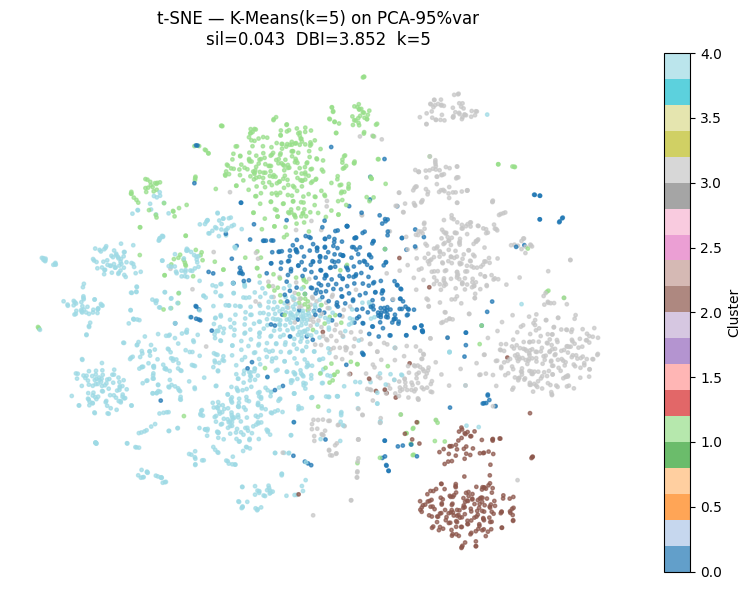

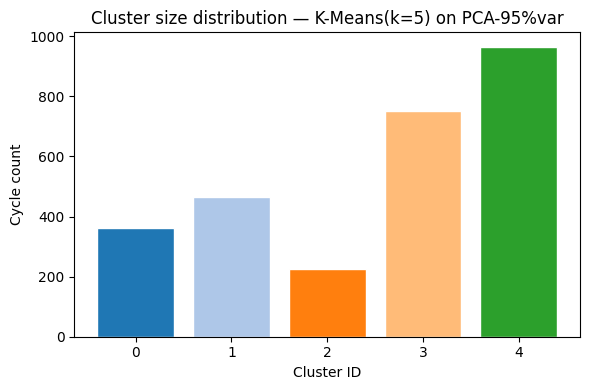

In [44]:

from sklearn.cluster import KMeans as _KMeans_diag

_km_pca95 = _KMeans_diag(n_clusters=N_CLUSTERS, init='k-means++',
                          n_init=20, max_iter=500, random_state=42)
labels_kmeans_pca95 = _km_pca95.fit_predict(X_pca95)

_eval_alt(labels_kmeans_pca95, 'kmeans_pca95', f'K-Means(k={N_CLUSTERS}) on PCA-95%var')


### 5.2 Gaussian Mixture Model (GMM) on PCA (≥95% var)

**Rationale:** GMM fits a separate full covariance matrix per component, allowing soft,
elliptical cluster boundaries. Rope flow patterns likely have non-spherical distributions
in PCA space due to within-class variability (e.g., speed, amplitude, and subject differences
within the same pattern type). k-means implicitly assumes spherical, equal-variance clusters —
GMM relaxes both assumptions. `n_init=10` re-fits from 10 random initialisations and keeps
the best log-likelihood solution.

[GMM(k=8, full covariance) on PCA-95%var]
  silhouette=0.0137  DBI=3.8099  n_clusters=8  noise_frac=0.0000  ARI_vs_kmeans=0.3242


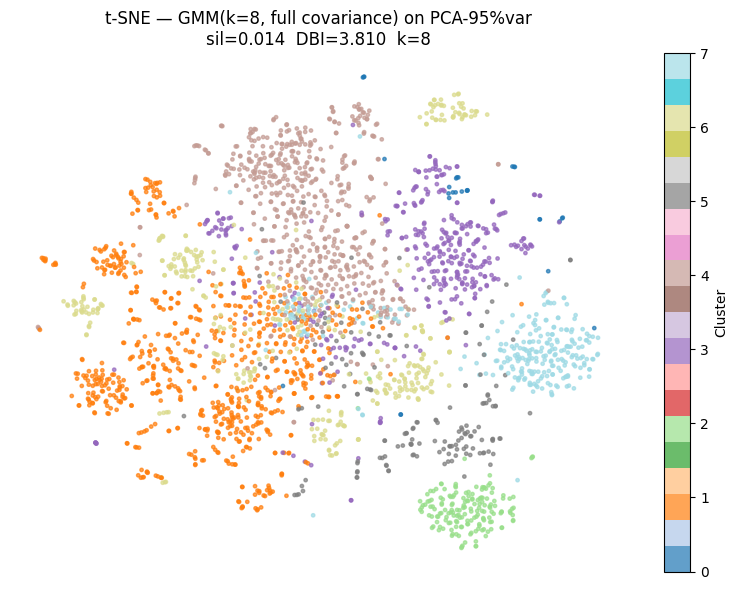

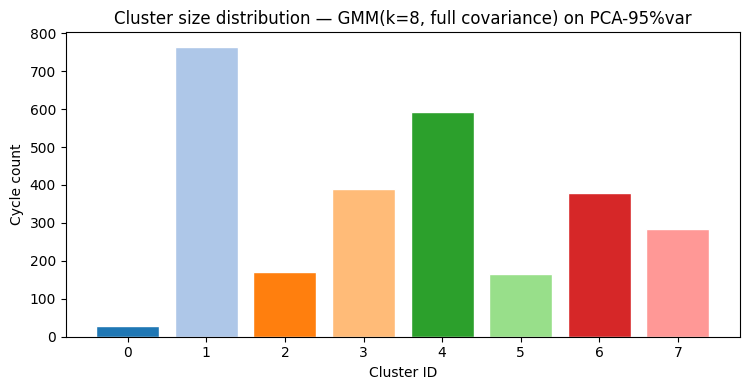

In [63]:

from sklearn.mixture import GaussianMixture as _GMM

# GMM requires float64; reg_covar adds diagonal regularisation to keep covariances PD.
_X64 = X_pca95.astype(np.float64)

_gmm = _GMM(n_components=N_CLUSTERS, covariance_type='full',
            n_init=10, reg_covar=1e-4, random_state=42)
labels_gmm = _gmm.fit_predict(_X64)

_eval_alt(labels_gmm, 'gmm', f'GMM(k={N_CLUSTERS}, full covariance) on PCA-95%var')


### 5.3 HDBSCAN on PCA-95%

**Rationale:** Density-based clustering does not require specifying k and naturally identifies
transition or ambiguous cycles as noise (label = −1) rather than forcing them into a cluster.
The number of clusters found is a useful diagnostic:

- **≈ N_CLUSTERS** → validates the current k assumption
- **Fewer than N_CLUSTERS** → some patterns are not separable in the current feature space
- **High noise fraction** → many transition cycles between pattern types; may indicate the
  fixed-window extraction captures mixed-phase cycles at pattern boundaries

`min_cluster_size=10`: at least 10 cycles required to form a cluster.  
`min_samples=5`: controls cluster stability — lower values are more permissive.  
Uses `sklearn.cluster.HDBSCAN` (available since sklearn 1.3 — no external build dependency).

HDBSCAN: 3 clusters found | 0.8% of cycles labelled as noise
  Diagnostic: N_CLUSTERS=12 — diverges by 9 — some patterns may not be separable
[HDBSCAN on PCA-95%var]
  silhouette=0.5300  DBI=1.5207  n_clusters=3  noise_frac=0.0083  ARI_vs_kmeans=-0.0003


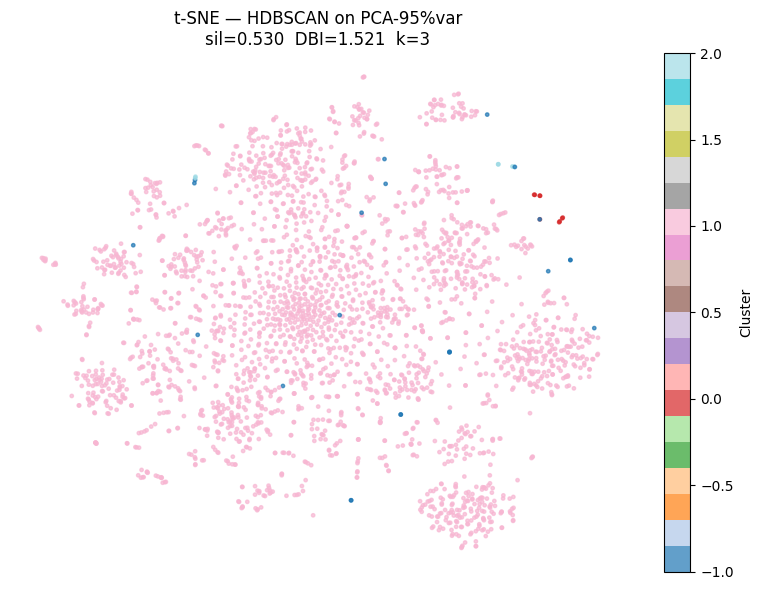

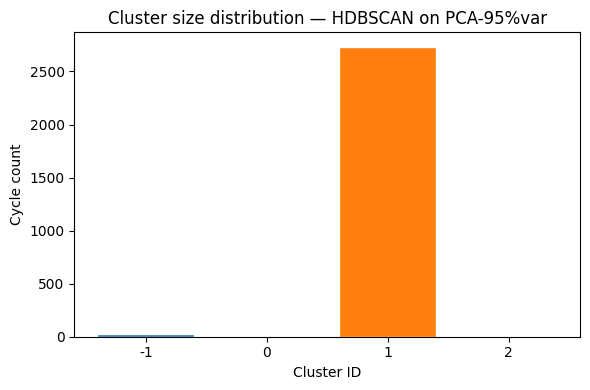

In [11]:

from sklearn.cluster import HDBSCAN as _HDBSCAN

_hdb = _HDBSCAN(min_cluster_size=5, min_samples=3, n_jobs=-1)
labels_hdbscan = _hdb.fit_predict(X_pca95)

_n_hdb  = len(np.unique(labels_hdbscan[labels_hdbscan != -1]))
_nf_hdb = 100.0 * (labels_hdbscan == -1).sum() / len(labels_hdbscan)
print(f'HDBSCAN: {_n_hdb} clusters found | {_nf_hdb:.1f}% of cycles labelled as noise')
print(f'  Diagnostic: N_CLUSTERS={N_CLUSTERS} — '
      + ('validates k assumption' if abs(_n_hdb - N_CLUSTERS) <= 2
         else f'diverges by {abs(_n_hdb - N_CLUSTERS)} — some patterns may not be separable'))

_eval_alt(labels_hdbscan, 'hdbscan', 'HDBSCAN on PCA-95%var')


### 5.4 Agglomerative Hierarchical Clustering on PCA (≥95% var)

**Rationale:** Ward linkage minimises within-cluster variance at each merge step, producing
compact, similarly sized clusters. The truncated dendrogram shows whether `N_CLUSTERS` is a
natural cut point in the data hierarchy or whether fewer groupings better describe the geometry.
A large jump in linkage distance just before the k-th cut indicates a well-separated natural
grouping; a smooth increase suggests k is imposed on a continuum.

[Agglomerative(k=12, ward) on PCA-95%var]
  silhouette=0.0304  DBI=3.6920  n_clusters=12  noise_frac=0.0000  ARI_vs_kmeans=0.3553


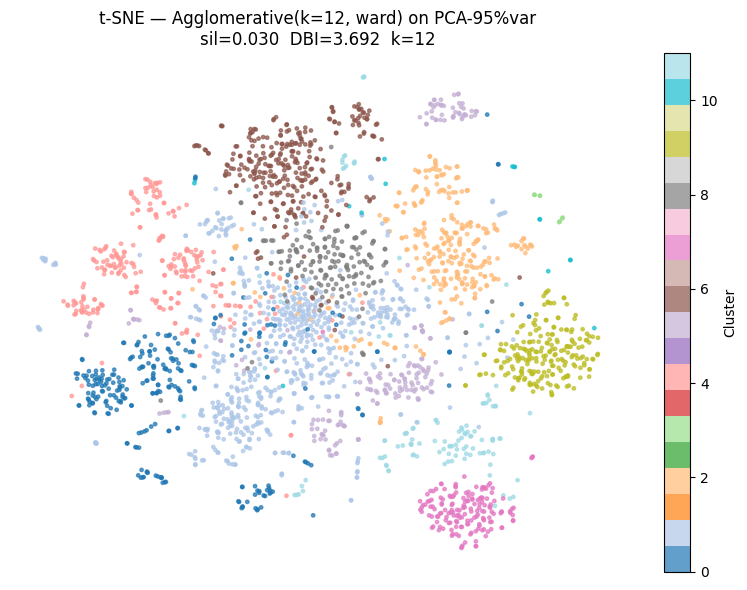

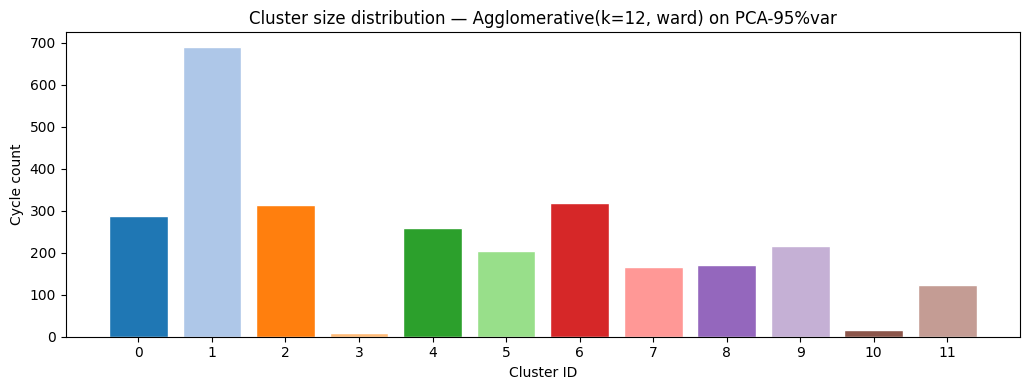

Computing ward linkage matrix on subsample n=600...


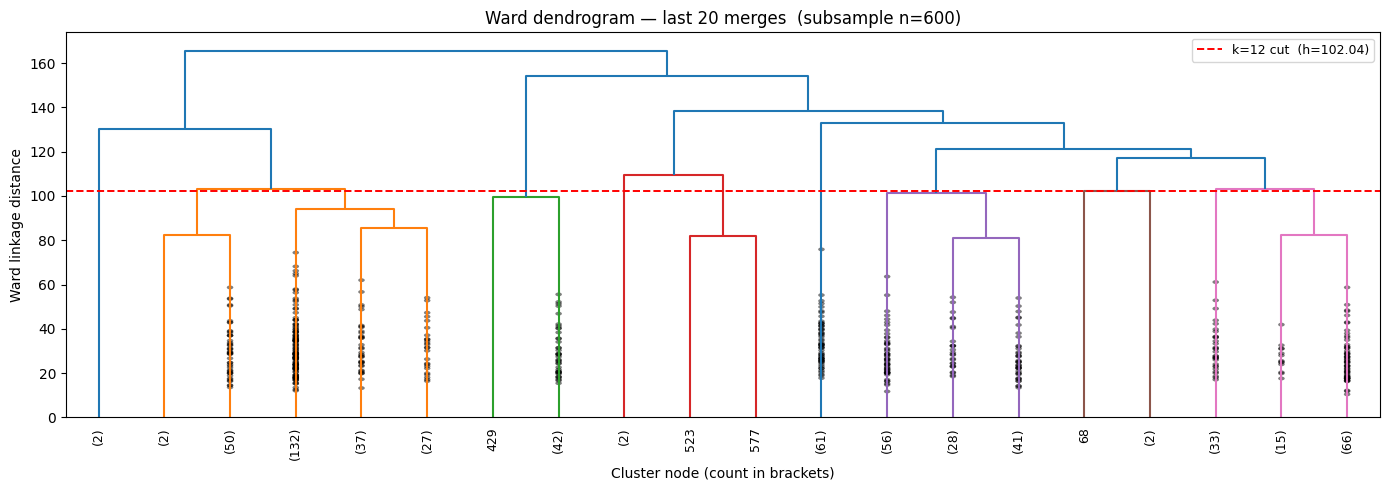

Dendrogram saved.


In [12]:

from sklearn.cluster import AgglomerativeClustering as _Agglom
from scipy.cluster.hierarchy import dendrogram, linkage as _scipy_linkage

_agglom = _Agglom(n_clusters=N_CLUSTERS, linkage='ward')
labels_agglomerative = _agglom.fit_predict(X_pca95)

_eval_alt(labels_agglomerative, 'agglomerative',
          f'Agglomerative(k={N_CLUSTERS}, ward) on PCA-95%var')

# ── Dendrogram truncated to last 20 merges ────────────────────────────────
_N_DEND = min(600, len(X_pca95))
_rng_d  = np.random.default_rng(42)
_idx_d  = _rng_d.choice(len(X_pca95), _N_DEND, replace=False)
print(f'Computing ward linkage matrix on subsample n={_N_DEND}...')
Z_ward = _scipy_linkage(X_pca95[_idx_d], method='ward', metric='euclidean')

fig_d, ax_d = plt.subplots(figsize=(14, 5))
dendrogram(Z_ward, truncate_mode='lastp', p=20, ax=ax_d,
           leaf_rotation=90, leaf_font_size=9, show_contracted=True)
ax_d.set_title(f'Ward dendrogram — last 20 merges  (subsample n={_N_DEND})')
ax_d.set_xlabel('Cluster node (count in brackets)')
ax_d.set_ylabel('Ward linkage distance')
_cut_h = Z_ward[-(N_CLUSTERS - 1), 2]
ax_d.axhline(_cut_h, color='r', ls='--', lw=1.4,
             label=f'k={N_CLUSTERS} cut  (h={_cut_h:.2f})')
ax_d.legend(fontsize=9)
fig_d.tight_layout()
fig_d.savefig(os.path.join(RESULTS_DIR, 'fig_dendrogram_ward.png'), dpi=120, bbox_inches='tight')
plt.show()
plt.close(fig_d)
print('Dendrogram saved.')


### 5.5 Summary Comparison Table

Collects metrics from all four methods plus the existing k-means baseline.

| Metric | Interpretation |
|---|---|
| **Silhouette** | Higher is better; measures inter-cluster separation relative to intra-cluster cohesion |
| **Davies-Bouldin index** | Lower is better; average ratio of within-cluster scatter to between-cluster separation |
| **n_clusters** | Clusters found — auto-discovered by HDBSCAN, fixed to `N_CLUSTERS` for others |
| **noise_frac** | Fraction of cycles assigned to noise class (HDBSCAN only; always 0 for others) |
| **ARI vs k-means** | Adjusted Rand Index vs. existing labels; 0 = random agreement, 1 = identical |

In [13]:

_sil_km_ref = _sil_score(X_pca95, global_clusters,
                          sample_size=min(2000, len(global_clusters)), random_state=42)
_dbi_km_ref = _dbi_score(X_pca95, global_clusters)
alt_results['kmeans_shape_norm'] = {
    'method':         f'K-Means(k={N_CLUSTERS}) shape-norm [EXISTING BASELINE]',
    'silhouette':     round(_sil_km_ref, 4),
    'davies_bouldin': round(_dbi_km_ref, 4),
    'n_clusters':     N_CLUSTERS,
    'noise_frac':     0.0,
    'ari_vs_kmeans':  1.0,
}

summary_df = pd.DataFrame(list(alt_results.values()))
summary_df = summary_df[['method', 'silhouette', 'davies_bouldin',
                          'n_clusters', 'noise_frac', 'ari_vs_kmeans']]
summary_df = summary_df.sort_values('silhouette', ascending=False).reset_index(drop=True)

print('\n' + '=' * 90)
print(f'ALTERNATIVE CLUSTERING COMPARISON  —  PCA (≥95% var, {X_pca95.shape[1]}D) of X_feat')
print('=' * 90)
print(summary_df.to_string(index=False))
print('=' * 90)
print('silhouette ↑ better  |  davies_bouldin ↓ better  |  noise_frac: HDBSCAN only')
summary_df.to_csv(os.path.join(RESULTS_DIR, 'alt_clustering_summary.csv'), index=False)
print(f'Table saved: {os.path.join(RESULTS_DIR, "alt_clustering_summary.csv")}')

balance = {}
for key, lbs in alt_labels.items():
    valid = lbs[lbs != -1]
    if len(valid) == 0:
        balance[key] = np.inf
        continue
    _, cnts = np.unique(valid, return_counts=True)
    balance[key] = float(cnts.std() / (cnts.mean() + 1e-8))

best_balance_key = min(balance, key=balance.get)
best_sil_row     = summary_df.loc[summary_df['silhouette'].idxmax()]
best_sil_key     = next(k for k, v in alt_results.items()
                        if v['method'] == best_sil_row['method']
                        and k != 'kmeans_shape_norm')

print(f'\nCluster size balance — CV (lower = more equal):')
for k, v in sorted(balance.items(), key=lambda x: x[1]):
    title = alt_results.get(k, {}).get('method', k)
    print(f'  {title:<55s}  CV={v:.3f}')

print(f'\nHighest silhouette : {best_sil_row["method"]}  '
      f'(sil={best_sil_row["silhouette"]:.4f})')
print(f'Most balanced sizes: {alt_results.get(best_balance_key, {}).get("method", best_balance_key)}  '
      f'(CV={balance[best_balance_key]:.3f})')

if best_sil_key == best_balance_key:
    print(f'\n>>> RECOMMENDED REPLACEMENT: {best_sil_row["method"]}')
    print('    Best on both silhouette score AND cluster size balance.')
else:
    bal_title = alt_results.get(best_balance_key, {}).get('method', best_balance_key)
    print('\n>>> Two different methods lead on different criteria:')
    print(f'    Highest silhouette : {best_sil_row["method"]}  '
          f'(sil={best_sil_row["silhouette"]:.4f})')
    print(f'    Most balanced sizes: {bal_title}  '
          f'(CV={balance[best_balance_key]:.3f})')
    print('    Inspect the t-SNE plots and the dendrogram before choosing a replacement.')
    print('    If HDBSCAN noise_frac is low (<5%) and n_clusters ≈ N_CLUSTERS,')
    print('    HDBSCAN is preferred as it avoids imposing a fixed k on the data.')



ALTERNATIVE CLUSTERING COMPARISON  —  PCA (≥95% var, 97D) of X_feat
                                      method  silhouette  davies_bouldin  n_clusters  noise_frac  ari_vs_kmeans
                       HDBSCAN on PCA-95%var      0.5300          1.5207           3      0.0083        -0.0003
                 K-Means(k=12) on PCA-95%var      0.0433          3.3560          12      0.0000         0.5030
     Agglomerative(k=12, ward) on PCA-95%var      0.0304          3.6920          12      0.0000         0.3553
    GMM(k=12, full covariance) on PCA-95%var      0.0261          3.7845          12      0.0000         0.3903
K-Means(k=12) shape-norm [EXISTING BASELINE]      0.0207          4.0464          12      0.0000         1.0000
silhouette ↑ better  |  davies_bouldin ↓ better  |  noise_frac: HDBSCAN only
Table saved: ..\..\results\Full_pipeline\run_20260426_095754\alt_clustering_summary.csv

Cluster size balance — CV (lower = more equal):
  K-Means(k=12) on PCA-95%var                

In [64]:
import json
from bisect import bisect_right

N_REPS_PER_CLUSTER   = 10
LABELED_SESSIONS_CSV = os.path.join('..', '..', 'results', 'labeled_sessions_with_time_labels.csv')
LABELED_RAW_BASE     = os.path.join('..', '..', 'data', 'raw', 'new-labeled-sessions')

LABEL_ALIAS_MAP = {
    'bf': 'dragon_roll', 'bf2': 'dragon_roll', 'fb': 'dragon_roll', 'fb2': 'dragon_roll',
    'dragon roll': 'dragon_roll', 'dragon_roll': 'dragon_roll',
    'ur': 'underhand_right', 'ur0': 'underhand_right',
    'underhand right': 'underhand_right', 'underhand': 'underhand_right',
    'ul': 'underhand_left', 'ul0': 'underhand_left',
    'underhand left': 'underhand_left',
    'ol': 'overhand_left', 'ol0': 'overhand_left', 'ol2': 'overhand_left',
    'overhand left': 'overhand_left', 'overhand': 'overhand_left',
    'or': 'overhand_right', 'or2': 'overhand_right', 'or3': 'overhand_right',
    'overhand right': 'overhand_right',
    'usl': 'sneak_underhand_left', 'sneak underhand left': 'sneak_underhand_left',
    'usr': 'sneak_underhand_right', 'sneak underhand right': 'sneak_underhand_right',
    'osl': 'sneak_overhand_left',  'sneak overhand left': 'sneak_overhand_left',
    'osr': 'sneak_overhand_right', 'sneak overhand right': 'sneak_overhand_right',
    'sneak overhand': 'sneak_overhand', 'sneak underhand': 'sneak_underhand',
    'cw': 'clockwise', 'clockwise': 'clockwise',
    'ccw': 'counter_clockwise', 'counter clockwise': 'counter_clockwise',
    'idle': 'idle', 'idle3': 'idle', 'no movement': 'idle',
    'excluded': 'excluded',
    'vq5': 'vq', 'vq15': 'vq', 'vq16': 'vq',
}

def _normalize_label_key(label):
    s = str(label).strip().lower().replace('_', ' ').replace('-', ' ')
    return ' '.join(s.split())

def canonicalize_label(label):
    key = _normalize_label_key(label)
    if key in LABEL_ALIAS_MAP:
        return LABEL_ALIAS_MAP[key]
    for sep in ('/', '|'):
        if sep in key:
            parts = [p.strip() for p in key.split(sep) if p.strip()]
            if parts:
                first = _normalize_label_key(parts[0])
                return LABEL_ALIAS_MAP.get(first, first)
    return key

def _extract_cycles_with_midtimes(entry, cfg):
    d0_path, d1_path, _, _, windows = entry
    d0, d1 = load_session(d0_path, d1_path)
    t0, _, A0, om0 = extract_signals(d0)
    t1, _, A1, om1 = extract_signals(d1)
    peaks0, _ = detect_cycle_peaks(om0, cfg['FS'], cfg)
    peaks1, _ = detect_cycle_peaks(om1, cfg['FS'], cfg)
    pairs = pair_peaks_same_swing(t0, peaks0, t1, peaks1, cfg['PEAK_PAIR_MAX_DT_S'])
    ch0 = np.column_stack([A0, om0 * (180.0 / np.pi)])
    ch1 = np.column_stack([A1, om1 * (180.0 / np.pi)])
    mats, mids = [], []
    for p0, p1 in pairs:
        t_mid = 0.5 * (t0[p0] + t1[p1])
        if windows is not None and not any(ws <= t_mid < we for ws, we in windows):
            continue
        w0 = extract_fixed_window(ch0, p0, cfg['WINDOW'])
        w1 = extract_fixed_window(ch1, p1, cfg['WINDOW'])
        mats.append(np.vstack([w0, w1]).astype(np.float32))
        mids.append(float(t_mid))
    return mats, mids

def _rebuild_cycle_metadata(entries, cfg):
    rows, idx = [], 0
    for e in entries:
        sid = e[3]
        _, mids = _extract_cycles_with_midtimes(e, cfg)
        for t_mid in mids:
            rows.append({'cycle_index': idx, 'session_id': sid, 't_mid_s': t_mid})
            idx += 1
    return pd.DataFrame(rows)

def _load_time_labels_for_session(session_id):
    session_dir = os.path.join(LABELED_RAW_BASE, session_id)
    if not os.path.isdir(session_dir):
        return None
    for name in ('labels_corrected.json', 'labels.json', 'labels_vad.json'):
        path = os.path.join(session_dir, name)
        if not os.path.isfile(path):
            continue
        with open(path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        segments    = data.get('segments',     []) or []
        label_events = data.get('label_events', []) or []
        if not segments and not label_events:
            continue
        clean_segs = [
            (float(s['start']), float(s['end']), canonicalize_label(s['label']))
            for s in segments if {'start', 'end', 'label'}.issubset(s)
        ]
        clean_evs = sorted(
            [(float(ev['time']), canonicalize_label(ev['label']))
             for ev in label_events if 'time' in ev and 'label' in ev],
            key=lambda x: x[0],
        )
        return {'json_path': path, 'source_name': name,
                'segments': clean_segs, 'events': clean_evs}
    return None

def _label_at_time(t_s, ann):
    for t0, t1, lab in ann['segments']:
        if t0 <= t_s < t1:
            return lab
    if ann['segments']:
        centers = np.array([(a + b) * 0.5 for a, b, _ in ann['segments']])
        return ann['segments'][int(np.argmin(np.abs(centers - t_s)))][2]
    if ann['events']:
        times = [e[0] for e in ann['events']]
        return ann['events'][max(0, bisect_right(times, t_s) - 1)][1]
    return None

def _project_cycles_for_cluster_space(X_cycles, sc, pca):
    Xn = X_cycles.copy()
    mu = Xn.mean(axis=2, keepdims=True)
    sd = Xn.std(axis=2,  keepdims=True) + 1e-8
    Xn = (Xn - mu) / sd
    return pca.transform(sc.transform(Xn.reshape(len(Xn), -1).astype(np.float32)))

# ── Locate labeled-sessions index CSV ─────────────────────────────────────
def _find_labeled_csv():
    fixed = os.path.abspath(LABELED_SESSIONS_CSV)
    if os.path.isfile(fixed):
        return fixed
    hits = glob.glob(
        os.path.join(os.path.abspath(os.path.join('..', '..', 'results')),
                     '**', 'labeled_sessions_with_time_labels.csv'),
        recursive=True,
    )
    return hits[0] if hits else None

csv_path = _find_labeled_csv()
if csv_path:
    labeled_index = pd.read_csv(csv_path)
    if 'session_id' not in labeled_index.columns:
        raise RuntimeError(f"'session_id' column missing in: {csv_path}")
    print(f'[info] Labeled sessions CSV: {csv_path}')
else:
    if not os.path.isdir(LABELED_RAW_BASE):
        raise FileNotFoundError(
            f'No CSV found and labeled-session folder missing.\n'
            f'  Expected CSV:    {LABELED_SESSIONS_CSV}\n'
            f'  Expected folder: {LABELED_RAW_BASE}'
        )
    rows = [
        {'session_id': sid}
        for sid in sorted(os.listdir(LABELED_RAW_BASE))
        if os.path.isdir(os.path.join(LABELED_RAW_BASE, sid))
        and any(os.path.isfile(os.path.join(LABELED_RAW_BASE, sid, fn))
                for fn in ('labels_corrected.json', 'labels.json', 'labels_vad.json'))
    ]
    if not rows:
        raise FileNotFoundError(f'No valid labeled-session folders under: {LABELED_RAW_BASE}')
    labeled_index = pd.DataFrame(rows)
    print(f'[warn] CSV not found — discovered {len(rows)} labeled session folders.')

labeled_sessions = sorted(labeled_index['session_id'].unique())

# ── Rebuild cycle midpoint metadata ───────────────────────────────────────
print(f'Rebuilding cycle midpoint metadata ({len(SESSIONS)} sessions)...')
cycle_meta = _rebuild_cycle_metadata(SESSIONS, DIRECT_CFG)
if len(cycle_meta) != len(X_cycles):
    raise RuntimeError(
        f'Metadata/cycle mismatch: meta={len(cycle_meta)} vs X_cycles={len(X_cycles)}'
    )

# ── Load per-session annotation JSONs ────────────────────────────────────
ann_cache = {}
for sid in labeled_sessions:
    try:
        ann = _load_time_labels_for_session(sid)
        if ann is not None:
            ann_cache[sid] = ann
    except Exception as e:
        print(f"[warn] Skipping '{sid}': {type(e).__name__}: {e}")

if not ann_cache:
    raise RuntimeError('No usable time-label annotations found.')
print(f'Annotations loaded: {len(ann_cache)}/{len(labeled_sessions)} sessions')
for sid in sorted(ann_cache):
    print(f'  {sid}: {ann_cache[sid]["source_name"]}')

# ── Project all cycles into the GMM feature space ─────────────────────
X_proj = _project_cycles_for_cluster_space(X_cycles, sc_global, pca_global).astype(np.float64)

# Use the fitted GMM object
gmm_model = _gmm if '_gmm' in globals() else gmm_global
n_expected = int(gmm_model.n_features_in_)
n_have = int(X_proj.shape[1])

# Dimensionality Alignment
if n_have == n_expected:
    X_proj_gmm = X_proj
elif n_have > n_expected:
    X_proj_gmm = X_proj[:, :n_expected]
else:
    # Rebuild if dimensions are insufficient
    Xflat = sc_global.transform(X_cycles.reshape(len(X_cycles), -1).astype(np.float32))
    Xfull = pca_global.transform(Xflat).astype(np.float64)
    X_proj_gmm = Xfull[:, :n_expected]

# Cluster Probabilities: P(Cluster | X)
probs = gmm_model.predict_proba(X_proj_gmm)

# ── 1. Identify Representatives (High Confidence) ──────────────────────
rep_rows = []
PROB_THRESHOLD = 0.8

# Ensure global_clusters is available from your GMM fit cell
for c in range(N_CLUSTERS):
    # Find cycles belonging to this cluster in the labeled dataset
    in_cluster = cand[cand['cluster'] == c].copy()
    if in_cluster.empty: continue
    
    idxs = in_cluster['cycle_index'].values.astype(int)
    in_cluster['p_cluster_given_x'] = probs[idxs, c]
    
    high_conf = in_cluster[in_cluster['p_cluster_given_x'] > PROB_THRESHOLD]
    
    for rank, (_, r) in enumerate(
        high_conf.nlargest(N_REPS_PER_CLUSTER, 'p_cluster_given_x').iterrows(), start=1
    ):
        rep_rows.append({
            'cluster': int(c), 'rank': rank, 'cycle_index': int(r['cycle_index']),
            'p_cluster_given_x': float(r['p_cluster_given_x']),
            'session_id': r['session_id'], 't_mid_s': float(r['t_mid_s']),
            'label': str(r['label']), 'label_json': ann_cache[r['session_id']]['json_path']
        })

df_labeled_reps = pd.DataFrame(rep_rows)

# ── 2. Soft Labeling: P(label | x) ────────────────────────────────────
# Use the probability matrix from your cluster-label analysis
# P_label_given_x = \sum_k P(label | C_k) * P(C_k | x)
# Note: Ensure P_label_given_cluster is the Pivot Table you generated earlier
# Create the cluster-to-label mapping matrix: P(label | cluster)
# Ensure clusters are rows (0 to N_CLUSTERS-1) and labels are columns
prob_pivot = prob.pivot_table(
    index='cluster', 
    columns='label', 
    values='p_label_given_cluster', 
    fill_value=0.0
).sort_index()

# Extract the labels (column names) for later use
ordered_labels = prob_pivot.columns.tolist()

# Convert to a NumPy array for the dot product
# Shape: (N_CLUSTERS, N_LABELS)
prob_matrix_values = prob_pivot.values.astype(np.float64)

print(f"[info] Transition matrix created: {prob_matrix_values.shape}")
P_label_given_x = probs @ prob_matrix_values 

# Define final hard labels and confidence
y_pred_idx = P_label_given_x.argmax(axis=1)
confidence = P_label_given_x.max(axis=1)

# ── 3. Summary & Export ───────────────────────────────────────────────
out_reps_csv = os.path.join(RESULTS_DIR, 'cluster_representatives_gmm_top10.csv')
df_labeled_reps.to_csv(out_reps_csv, index=False)

print(f'\nSaved: {out_reps_csv}')
if not df_labeled_reps.empty:
    cols = ['cluster', 'session_id', 't_mid_s', 'label', 'p_cluster_given_x']
    print(df_labeled_reps[df_labeled_reps['rank'] == 1][cols].to_string(index=False))

    # Calculate the probability of each label occurring within each cluster
prob = (
    cand.groupby(['cluster', 'label'])
        .size()
        .rename('count')
        .reset_index()
        .sort_values(['cluster', 'count'], ascending=[True, False])
)
prob['cluster_total'] = prob.groupby('cluster')['count'].transform('sum')
prob['p_label_given_cluster'] = prob['count'] / prob['cluster_total']

# Output the distribution for visual verification
print('\nTop labels per cluster (p(label|cluster)):')
for c in range(N_CLUSTERS):
    sub = prob[prob['cluster'] == c].head(3)
    if sub.empty:
        print(f'  C{c:02d}: No labeled cycles available')
    else:
        # Precision check: ensuring labels and their probabilities align
        parts = [f'{r.label} ({r.p_label_given_cluster:.2f})' for r in sub.itertuples()]
        print(f'  C{c:02d}: ' + ', '.join(parts))

[info] Labeled sessions CSV: c:\Users\Admin\Projects\ropeflow-project\results\labeled_sessions_with_time_labels.csv
Rebuilding cycle midpoint metadata (51 sessions)...
[warn] Skipping '20260315_155448_experimental_jo': TypeError: float() argument must be a string or a real number, not 'NoneType'
[warn] Skipping '20260315_182722_experimental_jo': TypeError: float() argument must be a string or a real number, not 'NoneType'
[warn] Skipping '20260316_172228_experimental_jo': TypeError: float() argument must be a string or a real number, not 'NoneType'
Annotations loaded: 9/12 sessions
  20260315_150630_experimental_jo: labels_corrected.json
  20260316_171550_experimental_jo: labels_corrected.json
  20260405_173949_experimental_progression: labels_corrected.json
  20260405_184437_experimental_bass-walk-down: labels_corrected.json
  20260405_184729_experimental_pachelbel: labels_corrected.json
  20260405_184905_experimental_pachelbel: labels_corrected.json
  20260405_185331_experimental_bir